In [1]:
# ============================================================
# PROJECT 17 — Data Drift & Pipeline Monitoring
# STEP 1 — LOAD DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Download Bank Marketing dataset
# ------------------------------------------------------------

url = (
    "https://archive.ics.uci.edu/"
    "ml/machine-learning-databases/00222/"
    "bank.zip"
)

print("=" * 70)
print("PROJECT 16 — FINANCIAL CUSTOMER DATA QUALITY")
print("=" * 70)

print("\nDownloading dataset...")

import requests
import zipfile
import io

response = requests.get(
    url,
    timeout=120
)

response.raise_for_status()

print(
    f"Downloaded: "
    f"{len(response.content) / (1024**2):.2f} MB"
)

# ------------------------------------------------------------
# Extract ZIP in memory
# ------------------------------------------------------------

with zipfile.ZipFile(
    io.BytesIO(response.content)
) as z:

    print("\nFiles inside ZIP:")
    print(z.namelist())

    # Read bank-full.csv
    with z.open(
        "bank-full.csv"
    ) as file:

        df = pd.read_csv(
            file,
            sep=";"
        )

# ------------------------------------------------------------
# Basic dataset information
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print(
    f"\nShape: {df.shape}"
)

print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)

print(
    "\nData types:"
)

print(
    df.dtypes
)

print(
    "\nFirst 5 rows:"
)

display(
    df.head()
)

PROJECT 16 — FINANCIAL CUSTOMER DATA QUALITY

Downloaded: 0.55 MB

Files inside ZIP:
['bank-full.csv', 'bank-names.txt', 'bank.csv']

DATASET INFORMATION

Shape: (45211, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# ============================================================
# PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING
# STEP 1 — RECREATE REFERENCE & CURRENT DATA
#             WITH PRESERVED SCHEMA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. Verify source dataset
# ------------------------------------------------------------

if "df" not in globals():
    raise ValueError(
        "Dataset 'df' belum tersedia. "
        "Jalankan Project 16 terlebih dahulu."
    )

print("=" * 80)
print("PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING")
print("=" * 80)

print(
    f"\nSource dataset shape: {df.shape}"
)

# ------------------------------------------------------------
# 2. Define monitored features
# ------------------------------------------------------------

numeric_features = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

categorical_features = [
    "job",
    "marital",
    "education",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

monitoring_features = (
    numeric_features
    +
    categorical_features
)

# ------------------------------------------------------------
# 3. Create reference dataset
# ------------------------------------------------------------

reference_df = (
    df[
        monitoring_features + ["y"]
    ]
    .sample(
        n=min(20000, len(df)),
        random_state=42
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. Create current dataset
# ------------------------------------------------------------

current_df = (
    df[
        monitoring_features + ["y"]
    ]
    .sample(
        n=min(20000, len(df)),
        random_state=2026
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 5. Preserve original data types
# ------------------------------------------------------------

original_dtypes = (
    reference_df[
        monitoring_features + ["y"]
    ]
    .dtypes
    .to_dict()
)

# ------------------------------------------------------------
# 6. Simulate controlled numerical drift
# ------------------------------------------------------------

rng = np.random.default_rng(42)

# Balance shift
balance_mask = (
    rng.random(
        len(current_df)
    ) < 0.35
)

current_df.loc[
    balance_mask,
    "balance"
] = np.round(
    current_df.loc[
        balance_mask,
        "balance"
    ] * 1.40
)

# Campaign shift
campaign_mask = (
    rng.random(
        len(current_df)
    ) < 0.30
)

current_df.loc[
    campaign_mask,
    "campaign"
] = (
    current_df.loc[
        campaign_mask,
        "campaign"
    ] + 2
)

# Duration shift
duration_mask = (
    rng.random(
        len(current_df)
    ) < 0.25
)

current_df.loc[
    duration_mask,
    "duration"
] = np.round(
    current_df.loc[
        duration_mask,
        "duration"
    ] * 1.25
)

# ------------------------------------------------------------
# 7. Simulate controlled categorical drift
# ------------------------------------------------------------

housing_mask = (
    rng.random(
        len(current_df)
    ) < 0.20
)

current_df.loc[
    housing_mask,
    "housing"
] = "no"

loan_mask = (
    rng.random(
        len(current_df)
    ) < 0.15
)

current_df.loc[
    loan_mask,
    "loan"
] = "yes"

# ------------------------------------------------------------
# 8. Restore schema to match reference
# ------------------------------------------------------------

for column in numeric_features:

    current_df[column] = (
        current_df[column]
        .round()
        .astype(
            original_dtypes[column]
        )
    )

for column in categorical_features:

    current_df[column] = (
        current_df[column]
        .astype(
            original_dtypes[column]
        )
    )

current_df["y"] = (
    current_df["y"]
    .astype(
        original_dtypes["y"]
    )
)

# ------------------------------------------------------------
# 9. Ensure column order is identical
# ------------------------------------------------------------

current_df = current_df[
    reference_df.columns
]

# ------------------------------------------------------------
# 10. Display schema
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SCHEMA VALIDATION BEFORE MONITORING")
print("=" * 80)

schema_preview = pd.DataFrame({
    "Column": reference_df.columns,
    "Reference_Dtype": [
        str(reference_df[col].dtype)
        for col in reference_df.columns
    ],
    "Current_Dtype": [
        str(current_df[col].dtype)
        for col in current_df.columns
    ]
})

schema_preview["Match"] = (
    schema_preview["Reference_Dtype"]
    ==
    schema_preview["Current_Dtype"]
)

display(
    schema_preview
)

# ------------------------------------------------------------
# 11. Compare numeric distributions
# ------------------------------------------------------------

reference_summary = (
    reference_df[
        numeric_features
    ]
    .describe()
    .T
)

current_summary = (
    current_df[
        numeric_features
    ]
    .describe()
    .T
)

comparison = pd.DataFrame({
    "Reference_Mean":
        reference_summary["mean"],
    "Current_Mean":
        current_summary["mean"],
    "Reference_Median":
        reference_summary["50%"],
    "Current_Median":
        current_summary["50%"]
})

comparison["Mean_Change_%"] = (
    (
        comparison["Current_Mean"]
        -
        comparison["Reference_Mean"]
    )
    /
    comparison["Reference_Mean"]
    * 100
)

print(
    "\nNumeric feature comparison:"
)

display(
    comparison
)

print(
    "\nReference shape:",
    reference_df.shape
)

print(
    "Current shape:",
    current_df.shape
)

PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING

Source dataset shape: (45211, 17)

SCHEMA VALIDATION BEFORE MONITORING


,Column,Reference_Dtype,Current_Dtype,Match
0,age,int64,int64,True
1,balance,int64,int64,True
2,duration,int64,int64,True
3,campaign,int64,int64,True
4,pdays,int64,int64,True
5,previous,int64,int64,True
6,job,object,object,True
7,marital,object,object,True
8,education,object,object,True
9,housing,object,object,True



Numeric feature comparison:


,Reference_Mean,Current_Mean,Reference_Median,Current_Median,Mean_Change_%
age,40.87220,40.81510,39.0,39.0,-0.139704
balance,1373.51890,1562.86080,453.5,506.0,13.785169
duration,258.09260,273.42520,180.0,190.0,5.940736
campaign,2.75780,3.37065,2.0,3.0,22.222424
pdays,40.43530,40.45475,-1.0,-1.0,0.048102
previous,0.59395,0.59105,0.0,0.0,-0.488257



Reference shape: (20000, 15)
Current shape: (20000, 15)


In [5]:
# ============================================================
# PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING
# STEP 2 — SCHEMA & DATA INTEGRITY MONITORING
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Compare schema
# ------------------------------------------------------------

reference_columns = list(
    reference_df.columns
)

current_columns = list(
    current_df.columns
)

missing_in_current = [
    col
    for col in reference_columns
    if col not in current_columns
]

new_in_current = [
    col
    for col in current_columns
    if col not in reference_columns
]

column_order_match = (
    reference_columns
    ==
    current_columns
)

# ------------------------------------------------------------
# 2. Compare data types
# ------------------------------------------------------------

common_columns = [
    col
    for col in reference_columns
    if col in current_columns
]

dtype_rows = []

for column in common_columns:

    reference_dtype = str(
        reference_df[column].dtype
    )

    current_dtype = str(
        current_df[column].dtype
    )

    dtype_match = (
        reference_dtype
        ==
        current_dtype
    )

    dtype_rows.append({
        "Column": column,
        "Reference_Dtype":
            reference_dtype,
        "Current_Dtype":
            current_dtype,
        "Match":
            dtype_match
    })

dtype_report = pd.DataFrame(
    dtype_rows
)

# ------------------------------------------------------------
# 3. Missing values
# ------------------------------------------------------------

reference_missing = (
    reference_df
    .isnull()
    .sum()
)

current_missing = (
    current_df
    .isnull()
    .sum()
)

missing_report = pd.DataFrame({
    "Column": common_columns,
    "Reference_Missing": [
        reference_missing[col]
        for col in common_columns
    ],
    "Current_Missing": [
        current_missing[col]
        for col in common_columns
    ]
})

missing_report[
    "Reference_Missing_Rate"
] = (
    missing_report[
        "Reference_Missing"
    ]
    /
    len(reference_df)
    * 100
)

missing_report[
    "Current_Missing_Rate"
] = (
    missing_report[
        "Current_Missing"
    ]
    /
    len(current_df)
    * 100
)

missing_report[
    "Missing_Rate_Change"
] = (
    missing_report[
        "Current_Missing_Rate"
    ]
    -
    missing_report[
        "Reference_Missing_Rate"
    ]
)

# ------------------------------------------------------------
# 4. Duplicate rate
# ------------------------------------------------------------

reference_duplicates = (
    reference_df
    .duplicated()
    .sum()
)

current_duplicates = (
    current_df
    .duplicated()
    .sum()
)

reference_duplicate_rate = (
    reference_duplicates
    /
    len(reference_df)
    * 100
)

current_duplicate_rate = (
    current_duplicates
    /
    len(current_df)
    * 100
)

# ------------------------------------------------------------
# 5. Integrity checks
# ------------------------------------------------------------

schema_integrity = (
    len(missing_in_current) == 0
    and
    len(new_in_current) == 0
    and
    column_order_match
)

dtype_integrity = (
    dtype_report["Match"].all()
)

missing_integrity = (
    current_missing.sum() == 0
)

duplicate_integrity = (
    current_duplicate_rate <= 1
)

overall_integrity = (
    schema_integrity
    and
    dtype_integrity
    and
    missing_integrity
    and
    duplicate_integrity
)

# ------------------------------------------------------------
# 6. Print schema monitoring
# ------------------------------------------------------------

print("=" * 80)
print("SCHEMA MONITORING")
print("=" * 80)

print(
    f"\nReference columns : "
    f"{len(reference_columns)}"
)

print(
    f"Current columns   : "
    f"{len(current_columns)}"
)

print(
    "\nMissing columns:"
)

print(
    missing_in_current
    if missing_in_current
    else "None"
)

print(
    "\nNew columns:"
)

print(
    new_in_current
    if new_in_current
    else "None"
)

print(
    "\nColumn order match:",
    column_order_match
)

# ------------------------------------------------------------
# 7. Data type monitoring
# ------------------------------------------------------------

print(
    "\nData type comparison:"
)

display(
    dtype_report
)

# ------------------------------------------------------------
# 8. Missing value monitoring
# ------------------------------------------------------------

print(
    "\nMissing value comparison:"
)

display(
    missing_report
)

# ------------------------------------------------------------
# 9. Duplicate monitoring
# ------------------------------------------------------------

print(
    "\nDuplicate monitoring:"
)

print(
    f"Reference duplicates : "
    f"{reference_duplicates:,}"
)

print(
    f"Current duplicates   : "
    f"{current_duplicates:,}"
)

print(
    f"Reference rate       : "
    f"{reference_duplicate_rate:.4f}%"
)

print(
    f"Current rate         : "
    f"{current_duplicate_rate:.4f}%"
)

# ------------------------------------------------------------
# 10. Final integrity dashboard
# ------------------------------------------------------------

integrity_report = pd.DataFrame({
    "Check": [
        "Schema Integrity",
        "Data Type Integrity",
        "Missing Value Integrity",
        "Duplicate Integrity",
        "Overall Data Integrity"
    ],
    "Status": [
        "PASS"
        if schema_integrity
        else "ALERT",

        "PASS"
        if dtype_integrity
        else "ALERT",

        "PASS"
        if missing_integrity
        else "ALERT",

        "PASS"
        if duplicate_integrity
        else "ALERT",

        "PASS"
        if overall_integrity
        else "ALERT"
    ]
})

print(
    "\n" + "=" * 80
)

print(
    "FINAL DATA INTEGRITY STATUS"
)

print(
    "=" * 80
)

display(
    integrity_report
)

SCHEMA MONITORING

Reference columns : 15
Current columns   : 15

Missing columns:
None

New columns:
None

Column order match: True

Data type comparison:


,Column,Reference_Dtype,Current_Dtype,Match
0,age,int64,int64,True
1,balance,int64,int64,True
2,duration,int64,int64,True
3,campaign,int64,int64,True
4,pdays,int64,int64,True
5,previous,int64,int64,True
6,job,object,object,True
7,marital,object,object,True
8,education,object,object,True
9,housing,object,object,True



Missing value comparison:


,Column,Reference_Missing,Current_Missing,Reference_Missing_Rate,Current_Missing_Rate,Missing_Rate_Change
0,age,0,0,0.0,0.0,0.0
1,balance,0,0,0.0,0.0,0.0
2,duration,0,0,0.0,0.0,0.0
3,campaign,0,0,0.0,0.0,0.0
4,pdays,0,0,0.0,0.0,0.0
5,previous,0,0,0.0,0.0,0.0
6,job,0,0,0.0,0.0,0.0
7,marital,0,0,0.0,0.0,0.0
8,education,0,0,0.0,0.0,0.0
9,housing,0,0,0.0,0.0,0.0



Duplicate monitoring:
Reference duplicates : 0
Current duplicates   : 0
Reference rate       : 0.0000%
Current rate         : 0.0000%

FINAL DATA INTEGRITY STATUS


,Check,Status
0,Schema Integrity,PASS
1,Data Type Integrity,PASS
2,Missing Value Integrity,PASS
3,Duplicate Integrity,PASS
4,Overall Data Integrity,PASS


POPULATION STABILITY INDEX (PSI)

Thresholds:
Low Drift      : PSI < 0.1
Moderate Drift : 0.1 <= PSI < 0.25
High Drift     : PSI >= 0.25

PSI Report:


,Feature,PSI,Drift_Level
0,campaign,0.157422,Moderate
1,balance,0.005477,Low
2,duration,0.003723,Low
3,age,0.000197,Low
4,previous,0.000049,Low
5,pdays,0.000003,Low



Drift Summary:
High Drift     : 0
Moderate Drift : 1
Low Drift      : 5

Overall Numeric Drift Status: MODERATE ALERT


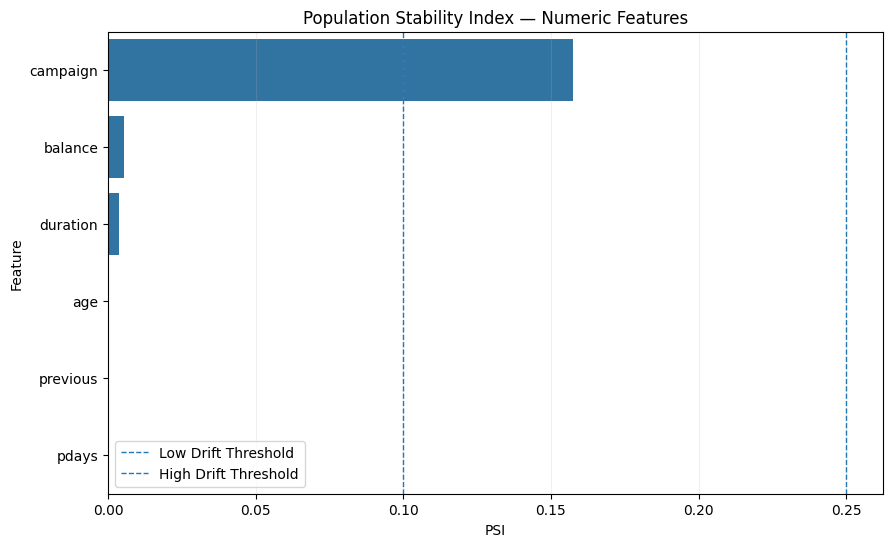

In [6]:
# ============================================================
# PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING
# STEP 3 — POPULATION STABILITY INDEX (PSI)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Define PSI thresholds
# ------------------------------------------------------------

PSI_LOW = 0.10
PSI_HIGH = 0.25

# ------------------------------------------------------------
# 2. PSI calculation function
# ------------------------------------------------------------

def calculate_psi(
    reference,
    current,
    bins=10
):
    """
    Calculate Population Stability Index (PSI)
    for one numeric feature.

    The reference distribution determines
    the bin boundaries, while the current
    distribution is evaluated using the same bins.
    """

    reference = (
        pd.Series(reference)
        .dropna()
        .astype(float)
    )

    current = (
        pd.Series(current)
        .dropna()
        .astype(float)
    )

    # --------------------------------------------------------
    # Handle constant / insufficient variation
    # --------------------------------------------------------

    if (
        reference.nunique() < 2
        or current.nunique() < 2
    ):
        return 0.0

    # --------------------------------------------------------
    # Create quantile-based bins from reference data
    # --------------------------------------------------------

    quantiles = np.linspace(
        0,
        1,
        bins + 1
    )

    bin_edges = (
        reference
        .quantile(quantiles)
        .values
    )

    bin_edges = np.unique(
        bin_edges
    )

    # Not enough unique values for requested bins
    if len(bin_edges) < 3:
        return 0.0

    # Make boundaries safely open-ended
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    # --------------------------------------------------------
    # Assign observations to bins
    # --------------------------------------------------------

    reference_bins = pd.cut(
        reference,
        bins=bin_edges,
        include_lowest=True
    )

    current_bins = pd.cut(
        current,
        bins=bin_edges,
        include_lowest=True
    )

    # --------------------------------------------------------
    # Calculate distributions
    # --------------------------------------------------------

    reference_dist = (
        reference_bins
        .value_counts(
            sort=False,
            normalize=True
        )
    )

    current_dist = (
        current_bins
        .value_counts(
            sort=False,
            normalize=True
        )
    )

    # --------------------------------------------------------
    # Add small epsilon to prevent log(0)
    # --------------------------------------------------------

    epsilon = 1e-6

    reference_dist = (
        reference_dist
        .replace(0, epsilon)
    )

    current_dist = (
        current_dist
        .replace(0, epsilon)
    )

    # --------------------------------------------------------
    # PSI formula
    # --------------------------------------------------------

    psi = (
        (
            current_dist
            -
            reference_dist
        )
        *
        np.log(
            current_dist
            /
            reference_dist
        )
    ).sum()

    return float(psi)

# ------------------------------------------------------------
# 3. Calculate PSI for numeric features
# ------------------------------------------------------------

psi_results = []

for feature in numeric_features:

    psi_value = calculate_psi(
        reference_df[feature],
        current_df[feature],
        bins=10
    )

    # --------------------------------------------------------
    # Assign drift severity
    # --------------------------------------------------------

    if psi_value < PSI_LOW:

        severity = "Low"

    elif psi_value < PSI_HIGH:

        severity = "Moderate"

    else:

        severity = "High"

    psi_results.append({
        "Feature": feature,
        "PSI": psi_value,
        "Drift_Level": severity
    })

psi_report = (
    pd.DataFrame(
        psi_results
    )
    .sort_values(
        "PSI",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. Display report
# ------------------------------------------------------------

print("=" * 80)
print("POPULATION STABILITY INDEX (PSI)")
print("=" * 80)

print(
    "\nThresholds:"
)

print(
    f"Low Drift      : PSI < {PSI_LOW}"
)

print(
    f"Moderate Drift : "
    f"{PSI_LOW} <= PSI < {PSI_HIGH}"
)

print(
    f"High Drift     : PSI >= {PSI_HIGH}"
)

print("\nPSI Report:")

display(
    psi_report
)

# ------------------------------------------------------------
# 5. Summary
# ------------------------------------------------------------

high_drift_count = (
    psi_report[
        "Drift_Level"
    ] == "High"
).sum()

moderate_drift_count = (
    psi_report[
        "Drift_Level"
    ] == "Moderate"
).sum()

low_drift_count = (
    psi_report[
        "Drift_Level"
    ] == "Low"
).sum()

print(
    "\nDrift Summary:"
)

print(
    f"High Drift     : "
    f"{high_drift_count}"
)

print(
    f"Moderate Drift : "
    f"{moderate_drift_count}"
)

print(
    f"Low Drift      : "
    f"{low_drift_count}"
)

# ------------------------------------------------------------
# 6. Overall numeric drift status
# ------------------------------------------------------------

if high_drift_count > 0:

    numeric_drift_status = "HIGH ALERT"

elif moderate_drift_count > 0:

    numeric_drift_status = "MODERATE ALERT"

else:

    numeric_drift_status = "PASS"

print(
    "\nOverall Numeric Drift Status:",
    numeric_drift_status
)

# ------------------------------------------------------------
# 7. Visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=psi_report,
    x="PSI",
    y="Feature"
)

plt.axvline(
    PSI_LOW,
    linestyle="--",
    linewidth=1,
    label="Low Drift Threshold"
)

plt.axvline(
    PSI_HIGH,
    linestyle="--",
    linewidth=1,
    label="High Drift Threshold"
)

plt.title(
    "Population Stability Index — Numeric Features"
)

plt.xlabel(
    "PSI"
)

plt.ylabel(
    "Feature"
)

plt.legend()

plt.grid(
    axis="x",
    alpha=0.2
)

plt.show()

KOLMOGOROV–SMIRNOV TEST

Significance level (alpha): 0.05

Interpretation:
p-value < alpha → statistically significant drift
p-value >= alpha → no statistically significant drift

KS Test Results:


,Feature,KS_Statistic,P_Value,Drift_Status
0,campaign,0.19290,0.000000e+00,Drift Detected
1,balance,0.02945,5.726934e-08,Drift Detected
2,duration,0.02685,1.072845e-06,Drift Detected
3,age,0.00445,9.884274e-01,No Significant Drift
4,previous,0.00215,1.000000e+00,No Significant Drift
5,pdays,0.00165,1.000000e+00,No Significant Drift



KS Drift Summary:
Drift detected      : 3
No significant drift: 3

Overall KS Status: STATISTICAL DRIFT DETECTED


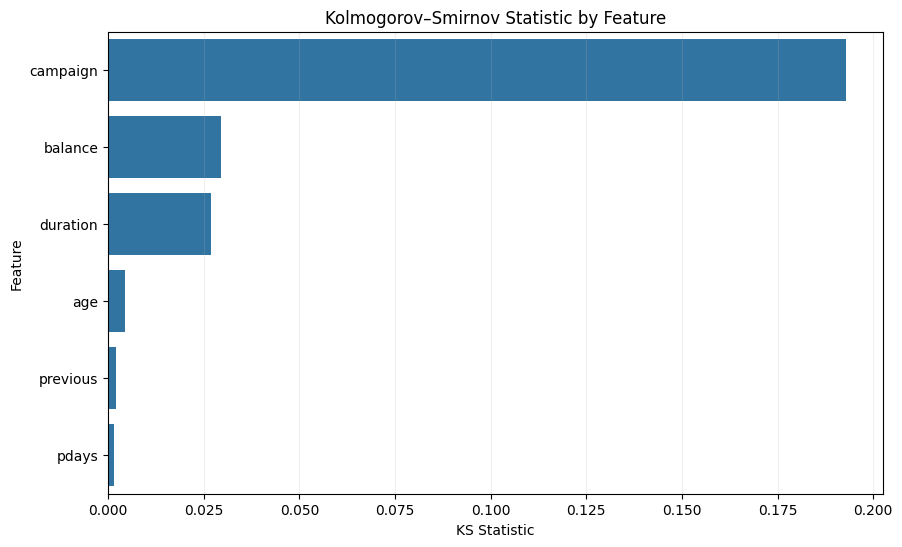

In [7]:
# ============================================================
# PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING
# STEP 4 — KOLMOGOROV–SMIRNOV TEST
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp

# ------------------------------------------------------------
# 1. Define significance level
# ------------------------------------------------------------

ALPHA = 0.05

# ------------------------------------------------------------
# 2. Run KS test for every numeric feature
# ------------------------------------------------------------

ks_results = []

for feature in numeric_features:

    reference_values = (
        reference_df[feature]
        .dropna()
        .values
    )

    current_values = (
        current_df[feature]
        .dropna()
        .values
    )

    # Two-sample Kolmogorov-Smirnov test
    statistic, p_value = ks_2samp(
        reference_values,
        current_values
    )

    # --------------------------------------------------------
    # Determine statistical drift
    # --------------------------------------------------------

    if p_value < ALPHA:
        drift_status = "Drift Detected"
    else:
        drift_status = "No Significant Drift"

    ks_results.append({
        "Feature": feature,
        "KS_Statistic": statistic,
        "P_Value": p_value,
        "Drift_Status": drift_status
    })

ks_report = (
    pd.DataFrame(
        ks_results
    )
    .sort_values(
        "KS_Statistic",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("=" * 80)
print("KOLMOGOROV–SMIRNOV TEST")
print("=" * 80)

print(
    f"\nSignificance level (alpha): {ALPHA}"
)

print(
    "\nInterpretation:"
)

print(
    "p-value < alpha → statistically significant drift"
)

print(
    "p-value >= alpha → no statistically significant drift"
)

print(
    "\nKS Test Results:"
)

display(
    ks_report
)

# ------------------------------------------------------------
# 4. Count drifted features
# ------------------------------------------------------------

ks_drift_count = (
    ks_report[
        "Drift_Status"
    ]
    == "Drift Detected"
).sum()

ks_no_drift_count = (
    ks_report[
        "Drift_Status"
    ]
    == "No Significant Drift"
).sum()

print(
    "\nKS Drift Summary:"
)

print(
    f"Drift detected      : "
    f"{ks_drift_count}"
)

print(
    f"No significant drift: "
    f"{ks_no_drift_count}"
)

# ------------------------------------------------------------
# 5. Overall KS status
# ------------------------------------------------------------

if ks_drift_count > 0:
    ks_overall_status = "STATISTICAL DRIFT DETECTED"
else:
    ks_overall_status = "PASS"

print(
    "\nOverall KS Status:",
    ks_overall_status
)

# ------------------------------------------------------------
# 6. Visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=ks_report,
    x="KS_Statistic",
    y="Feature"
)

plt.title(
    "Kolmogorov–Smirnov Statistic by Feature"
)

plt.xlabel(
    "KS Statistic"
)

plt.ylabel(
    "Feature"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.show()

CATEGORICAL DRIFT MONITORING

Thresholds:
Low TVD       : < 0.05
Moderate TVD  : 0.05 <= TVD < 0.1
High TVD      : >= 0.1

Significance level:
Alpha = 0.05

Categorical Drift Report:


,Feature,Chi2_Statistic,P_Value,TVD,Drift_Level,Statistical_Status
0,loan,887.171799,6.033087e-195,0.12395,High,Statistically Significant
1,housing,457.960835,1.335522e-101,0.10705,High,Statistically Significant
2,job,3.814954,9.750206e-01,0.00775,Low,No Significant Difference
3,education,2.389126,4.956620e-01,0.00755,Low,No Significant Difference
4,month,4.232327,9.626213e-01,0.00535,Low,No Significant Difference
5,marital,2.294871,3.174499e-01,0.00475,Low,No Significant Difference
6,poutcome,3.042376,3.851376e-01,0.00360,Low,No Significant Difference
7,contact,0.532808,7.661297e-01,0.00210,Low,No Significant Difference



Categorical Drift Summary:
High Drift             : 2
Moderate Drift         : 0
Low Drift              : 6
Statistically Significant: 2


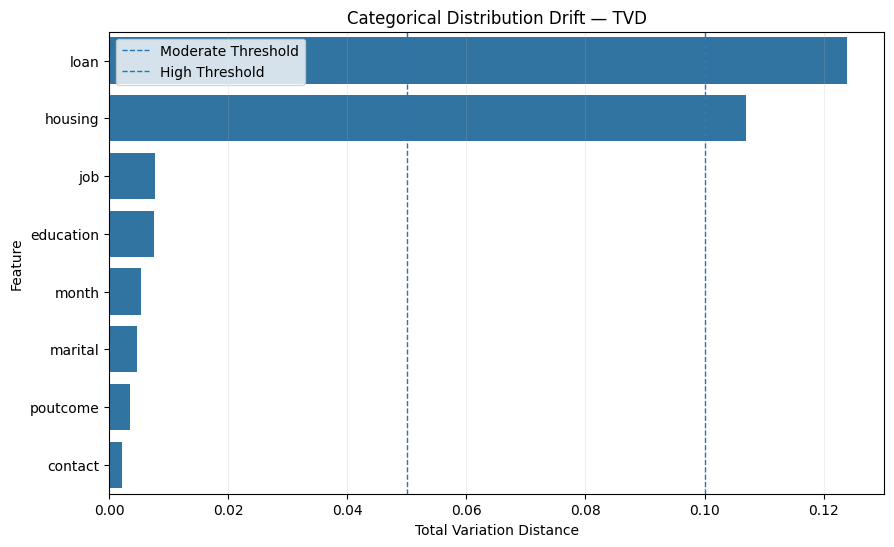


----------------------------------------------------------------------
Distribution comparison: housing
TVD: 0.107050


,Reference,Current
housing,,
yes,0.5542,0.44715
no,0.4458,0.55285



----------------------------------------------------------------------
Distribution comparison: loan
TVD: 0.123950


,Reference,Current
loan,,
no,0.8394,0.71545
yes,0.1606,0.28455


In [8]:
# ============================================================
# PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING
# STEP 5 — CATEGORICAL DRIFT MONITORING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

# ------------------------------------------------------------
# 1. Thresholds
# ------------------------------------------------------------

ALPHA = 0.05

TVD_LOW = 0.05
TVD_MODERATE = 0.10

# ------------------------------------------------------------
# 2. Function to calculate categorical drift
# ------------------------------------------------------------

def calculate_categorical_drift(
    reference,
    current
):

    reference = (
        reference
        .fillna("__MISSING__")
        .astype(str)
    )

    current = (
        current
        .fillna("__MISSING__")
        .astype(str)
    )

    # --------------------------------------------------------
    # Combine category universe
    # --------------------------------------------------------

    categories = sorted(
        set(reference.unique())
        |
        set(current.unique())
    )

    reference_counts = (
        reference
        .value_counts()
        .reindex(
            categories,
            fill_value=0
        )
    )

    current_counts = (
        current
        .value_counts()
        .reindex(
            categories,
            fill_value=0
        )
    )

    # --------------------------------------------------------
    # Convert to proportions
    # --------------------------------------------------------

    reference_distribution = (
        reference_counts
        /
        reference_counts.sum()
    )

    current_distribution = (
        current_counts
        /
        current_counts.sum()
    )

    # --------------------------------------------------------
    # Chi-Square contingency table
    # --------------------------------------------------------

    contingency_table = np.array([
        reference_counts.values,
        current_counts.values
    ])

    chi2, p_value, dof, expected = (
        chi2_contingency(
            contingency_table
        )
    )

    # --------------------------------------------------------
    # Total Variation Distance
    #
    # TVD = 0.5 * sum(|P - Q|)
    # --------------------------------------------------------

    tvd = (
        0.5
        *
        np.abs(
            reference_distribution.values
            -
            current_distribution.values
        ).sum()
    )

    return {
        "Chi2_Statistic": chi2,
        "P_Value": p_value,
        "TVD": tvd,
        "Reference_Distribution":
            reference_distribution,
        "Current_Distribution":
            current_distribution
    }

# ------------------------------------------------------------
# 3. Calculate categorical drift
# ------------------------------------------------------------

categorical_drift_results = []

category_distributions = {}

for feature in categorical_features:

    result = calculate_categorical_drift(
        reference_df[feature],
        current_df[feature]
    )

    # --------------------------------------------------------
    # Determine practical drift severity
    # --------------------------------------------------------

    if result["TVD"] < TVD_LOW:

        drift_level = "Low"

    elif result["TVD"] < TVD_MODERATE:

        drift_level = "Moderate"

    else:

        drift_level = "High"

    # --------------------------------------------------------
    # Statistical significance
    # --------------------------------------------------------

    if result["P_Value"] < ALPHA:

        statistical_status = (
            "Statistically Significant"
        )

    else:

        statistical_status = (
            "No Significant Difference"
        )

    categorical_drift_results.append({
        "Feature": feature,
        "Chi2_Statistic":
            result["Chi2_Statistic"],
        "P_Value":
            result["P_Value"],
        "TVD":
            result["TVD"],
        "Drift_Level":
            drift_level,
        "Statistical_Status":
            statistical_status
    })

    category_distributions[
        feature
    ] = {
        "reference":
            result[
                "Reference_Distribution"
            ],
        "current":
            result[
                "Current_Distribution"
            ]
    }

# ------------------------------------------------------------
# 4. Create report
# ------------------------------------------------------------

categorical_drift_report = (
    pd.DataFrame(
        categorical_drift_results
    )
    .sort_values(
        "TVD",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 5. Display report
# ------------------------------------------------------------

print("=" * 80)
print("CATEGORICAL DRIFT MONITORING")
print("=" * 80)

print(
    "\nThresholds:"
)

print(
    f"Low TVD       : < {TVD_LOW}"
)

print(
    f"Moderate TVD  : "
    f"{TVD_LOW} <= TVD < {TVD_MODERATE}"
)

print(
    f"High TVD      : >= {TVD_MODERATE}"
)

print(
    "\nSignificance level:"
)

print(
    f"Alpha = {ALPHA}"
)

print(
    "\nCategorical Drift Report:"
)

display(
    categorical_drift_report
)

# ------------------------------------------------------------
# 6. Summary
# ------------------------------------------------------------

high_categorical_drift = (
    categorical_drift_report[
        "Drift_Level"
    ] == "High"
).sum()

moderate_categorical_drift = (
    categorical_drift_report[
        "Drift_Level"
    ] == "Moderate"
).sum()

low_categorical_drift = (
    categorical_drift_report[
        "Drift_Level"
    ] == "Low"
).sum()

statistically_significant = (
    categorical_drift_report[
        "Statistical_Status"
    ]
    ==
    "Statistically Significant"
).sum()

print(
    "\nCategorical Drift Summary:"
)

print(
    f"High Drift             : "
    f"{high_categorical_drift}"
)

print(
    f"Moderate Drift         : "
    f"{moderate_categorical_drift}"
)

print(
    f"Low Drift              : "
    f"{low_categorical_drift}"
)

print(
    f"Statistically Significant: "
    f"{statistically_significant}"
)

# ------------------------------------------------------------
# 7. Visualize TVD
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=categorical_drift_report,
    x="TVD",
    y="Feature"
)

plt.axvline(
    TVD_LOW,
    linestyle="--",
    linewidth=1,
    label="Moderate Threshold"
)

plt.axvline(
    TVD_MODERATE,
    linestyle="--",
    linewidth=1,
    label="High Threshold"
)

plt.title(
    "Categorical Distribution Drift — TVD"
)

plt.xlabel(
    "Total Variation Distance"
)

plt.ylabel(
    "Feature"
)

plt.legend()

plt.grid(
    axis="x",
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 8. Detailed distribution comparison
# ------------------------------------------------------------

for feature in categorical_features:

    reference_dist = (
        category_distributions[
            feature
        ]["reference"]
    )

    current_dist = (
        category_distributions[
            feature
        ]["current"]
    )

    distribution_compare = pd.DataFrame({
        "Reference": reference_dist,
        "Current": current_dist
    })

    distribution_compare = (
        distribution_compare
        .sort_values(
            "Reference",
            ascending=False
        )
    )

    # Display only features with meaningful movement
    tvd_value = (
        categorical_drift_report
        .loc[
            categorical_drift_report[
                "Feature"
            ] == feature,
            "TVD"
        ]
        .iloc[0]
    )

    if tvd_value >= TVD_LOW:

        print(
            "\n" + "-" * 70
        )

        print(
            f"Distribution comparison: "
            f"{feature}"
        )

        print(
            f"TVD: {tvd_value:.6f}"
        )

        display(
            distribution_compare
        )

In [9]:
# ============================================================
# PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING
# STEP 6 — UNIFIED DRIFT MONITORING
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Prepare numeric drift report
# ------------------------------------------------------------

numeric_drift = psi_report.copy()

# Add KS information
numeric_drift = numeric_drift.merge(
    ks_report[
        [
            "Feature",
            "KS_Statistic",
            "P_Value",
            "Drift_Status"
        ]
    ],
    on="Feature",
    how="left"
)

numeric_drift["Data_Type"] = "Numeric"

# ------------------------------------------------------------
# 2. Create numeric unified status
# ------------------------------------------------------------

def numeric_unified_status(row):

    psi_level = row["Drift_Level"]
    ks_significant = (
        row["P_Value"] < 0.05
    )

    if (
        psi_level == "High"
        and
        ks_significant
    ):
        return "HIGH ALERT"

    elif (
        psi_level == "Moderate"
        and
        ks_significant
    ):
        return "MODERATE ALERT"

    elif (
        psi_level in ["High", "Moderate"]
        or
        ks_significant
    ):
        return "INVESTIGATE"

    else:
        return "PASS"

numeric_drift[
    "Unified_Status"
] = (
    numeric_drift.apply(
        numeric_unified_status,
        axis=1
    )
)

# ------------------------------------------------------------
# 3. Prepare categorical drift report
# ------------------------------------------------------------

categorical_drift = (
    categorical_drift_report.copy()
)

categorical_drift["Data_Type"] = (
    "Categorical"
)

# ------------------------------------------------------------
# 4. Create categorical unified status
# ------------------------------------------------------------

def categorical_unified_status(row):

    tvd_level = row["Drift_Level"]

    statistically_significant = (
        row["P_Value"] < 0.05
    )

    if (
        tvd_level == "High"
        and
        statistically_significant
    ):
        return "HIGH ALERT"

    elif (
        tvd_level == "Moderate"
        and
        statistically_significant
    ):
        return "MODERATE ALERT"

    elif (
        tvd_level in ["High", "Moderate"]
        or
        statistically_significant
    ):
        return "INVESTIGATE"

    else:
        return "PASS"

categorical_drift[
    "Unified_Status"
] = (
    categorical_drift.apply(
        categorical_unified_status,
        axis=1
    )
)

# ------------------------------------------------------------
# 5. Standardize columns for combined report
# ------------------------------------------------------------

numeric_unified = numeric_drift[
    [
        "Feature",
        "Data_Type",
        "PSI",
        "KS_Statistic",
        "P_Value",
        "Drift_Level",
        "Unified_Status"
    ]
].copy()

categorical_unified = categorical_drift[
    [
        "Feature",
        "Data_Type",
        "TVD",
        "Chi2_Statistic",
        "P_Value",
        "Drift_Level",
        "Unified_Status"
    ]
].copy()

# Add unavailable fields
numeric_unified["TVD"] = np.nan
numeric_unified["Chi2_Statistic"] = np.nan

categorical_unified["PSI"] = np.nan
categorical_unified["KS_Statistic"] = np.nan

# Reorder
numeric_unified = numeric_unified[
    [
        "Feature",
        "Data_Type",
        "PSI",
        "TVD",
        "KS_Statistic",
        "Chi2_Statistic",
        "P_Value",
        "Drift_Level",
        "Unified_Status"
    ]
]

categorical_unified = categorical_unified[
    [
        "Feature",
        "Data_Type",
        "PSI",
        "TVD",
        "KS_Statistic",
        "Chi2_Statistic",
        "P_Value",
        "Drift_Level",
        "Unified_Status"
    ]
]

# ------------------------------------------------------------
# 6. Combine all features
# ------------------------------------------------------------

unified_drift_report = pd.concat(
    [
        numeric_unified,
        categorical_unified
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# 7. Add severity ranking
# ------------------------------------------------------------

severity_priority = {
    "HIGH ALERT": 1,
    "MODERATE ALERT": 2,
    "INVESTIGATE": 3,
    "PASS": 4
}

unified_drift_report[
    "Priority"
] = (
    unified_drift_report[
        "Unified_Status"
    ].map(
        severity_priority
    )
)

unified_drift_report = (
    unified_drift_report
    .sort_values(
        [
            "Priority",
            "Data_Type",
            "Feature"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 8. Display unified report
# ------------------------------------------------------------

print("=" * 90)
print("UNIFIED DATA DRIFT REPORT")
print("=" * 90)

display(
    unified_drift_report[
        [
            "Feature",
            "Data_Type",
            "PSI",
            "TVD",
            "KS_Statistic",
            "Chi2_Statistic",
            "P_Value",
            "Drift_Level",
            "Unified_Status"
        ]
    ]
)

# ------------------------------------------------------------
# 9. Summary
# ------------------------------------------------------------

status_summary = (
    unified_drift_report[
        "Unified_Status"
    ]
    .value_counts()
)

print(
    "\nUnified Drift Status Summary:"
)

display(
    status_summary
)

# ------------------------------------------------------------
# 10. Overall status
# ------------------------------------------------------------

if (
    "HIGH ALERT"
    in
    unified_drift_report[
        "Unified_Status"
    ].values
):

    overall_drift_status = "HIGH ALERT"

elif (
    "MODERATE ALERT"
    in
    unified_drift_report[
        "Unified_Status"
    ].values
):

    overall_drift_status = (
        "MODERATE ALERT"
    )

elif (
    "INVESTIGATE"
    in
    unified_drift_report[
        "Unified_Status"
    ].values
):

    overall_drift_status = (
        "INVESTIGATE"
    )

else:

    overall_drift_status = "PASS"

print(
    "\nOverall Drift Status:",
    overall_drift_status
)

# ------------------------------------------------------------
# 11. List affected features
# ------------------------------------------------------------

affected_features = (
    unified_drift_report[
        unified_drift_report[
            "Unified_Status"
        ] != "PASS"
    ]
)

print(
    "\nFeatures requiring attention:"
)

if len(affected_features) > 0:

    display(
        affected_features[
            [
                "Feature",
                "Data_Type",
                "Drift_Level",
                "Unified_Status"
            ]
        ]
    )

else:

    print(
        "No features require attention."
    )

UNIFIED DATA DRIFT REPORT


,Feature,Data_Type,PSI,TVD,KS_Statistic,Chi2_Statistic,P_Value,Drift_Level,Unified_Status
0,housing,Categorical,NaN,0.10705,NaN,457.960835,1.335522e-101,High,HIGH ALERT
1,loan,Categorical,NaN,0.12395,NaN,887.171799,6.033087e-195,High,HIGH ALERT
2,campaign,Numeric,0.157422,NaN,0.19290,NaN,0.000000e+00,Moderate,MODERATE ALERT
3,balance,Numeric,0.005477,NaN,0.02945,NaN,5.726934e-08,Low,INVESTIGATE
4,duration,Numeric,0.003723,NaN,0.02685,NaN,1.072845e-06,Low,INVESTIGATE
5,contact,Categorical,NaN,0.00210,NaN,0.532808,7.661297e-01,Low,PASS
6,education,Categorical,NaN,0.00755,NaN,2.389126,4.956620e-01,Low,PASS
7,job,Categorical,NaN,0.00775,NaN,3.814954,9.750206e-01,Low,PASS
8,marital,Categorical,NaN,0.00475,NaN,2.294871,3.174499e-01,Low,PASS
9,month,Categorical,NaN,0.00535,NaN,4.232327,9.626213e-01,Low,PASS



Unified Drift Status Summary:


,count
Unified_Status,
PASS,9
HIGH ALERT,2
INVESTIGATE,2
MODERATE ALERT,1



Overall Drift Status: HIGH ALERT

Features requiring attention:


,Feature,Data_Type,Drift_Level,Unified_Status
0,housing,Categorical,High,HIGH ALERT
1,loan,Categorical,High,HIGH ALERT
2,campaign,Numeric,Moderate,MODERATE ALERT
3,balance,Numeric,Low,INVESTIGATE
4,duration,Numeric,Low,INVESTIGATE


In [10]:
# ============================================================
# PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING
# STEP 7 — AUTOMATED DRIFT ALERT SYSTEM
# ============================================================

import pandas as pd
import numpy as np
from datetime import datetime

# ------------------------------------------------------------
# 1. Define alert configuration
# ------------------------------------------------------------

ALERT_PRIORITY = {
    "HIGH ALERT": 1,
    "MODERATE ALERT": 2,
    "INVESTIGATE": 3,
    "PASS": 4
}

# ------------------------------------------------------------
# 2. Copy unified drift report
# ------------------------------------------------------------

alert_report = (
    unified_drift_report
    .copy()
)

# ------------------------------------------------------------
# 3. Generate recommended action
# ------------------------------------------------------------

def get_action(status):

    if status == "HIGH ALERT":

        return (
            "Immediate investigation of "
            "current data distribution"
        )

    elif status == "MODERATE ALERT":

        return (
            "Review feature distribution "
            "and monitor next data batch"
        )

    elif status == "INVESTIGATE":

        return (
            "Check statistical significance "
            "and business context"
        )

    else:

        return (
            "No immediate action required"
        )

alert_report["Recommended_Action"] = (
    alert_report[
        "Unified_Status"
    ]
    .apply(get_action)
)

# ------------------------------------------------------------
# 4. Priority
# ------------------------------------------------------------

alert_report["Priority"] = (
    alert_report[
        "Unified_Status"
    ]
    .map(ALERT_PRIORITY)
)

alert_report = (
    alert_report
    .sort_values(
        [
            "Priority",
            "Feature"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 5. Generate alert messages
# ------------------------------------------------------------

alert_messages = []

for _, row in alert_report.iterrows():

    status = row["Unified_Status"]

    if status == "PASS":
        continue

    feature = row["Feature"]
    data_type = row["Data_Type"]

    if data_type == "Numeric":

        if pd.notna(row["PSI"]):
            metric_text = (
                f"PSI={row['PSI']:.6f}"
            )
        else:
            metric_text = "Numeric drift detected"

    else:

        if pd.notna(row["TVD"]):
            metric_text = (
                f"TVD={row['TVD']:.6f}"
            )
        else:
            metric_text = "Categorical drift detected"

    alert_messages.append({
        "Feature": feature,
        "Type": data_type,
        "Alert_Level": status,
        "Metric": metric_text,
        "Action": row[
            "Recommended_Action"
        ]
    })

alert_messages = pd.DataFrame(
    alert_messages
)

# ------------------------------------------------------------
# 6. Generate alert summary
# ------------------------------------------------------------

high_alerts = (
    alert_report[
        alert_report[
            "Unified_Status"
        ] == "HIGH ALERT"
    ]
)

moderate_alerts = (
    alert_report[
        alert_report[
            "Unified_Status"
        ] == "MODERATE ALERT"
    ]
)

investigation_items = (
    alert_report[
        alert_report[
            "Unified_Status"
        ] == "INVESTIGATE"
    ]
)

# ------------------------------------------------------------
# 7. Overall status
# ------------------------------------------------------------

if len(high_alerts) > 0:

    system_status = "HIGH ALERT"

elif len(moderate_alerts) > 0:

    system_status = "MODERATE ALERT"

elif len(investigation_items) > 0:

    system_status = "INVESTIGATE"

else:

    system_status = "PASS"

# ------------------------------------------------------------
# 8. Display alert dashboard
# ------------------------------------------------------------

print("=" * 90)
print("AUTOMATED DATA DRIFT ALERT SYSTEM")
print("=" * 90)

print(
    f"\nMonitoring Time:"
)

print(
    datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    )
)

print(
    f"\nSYSTEM STATUS: {system_status}"
)

print(
    f"\nHigh Alerts      : "
    f"{len(high_alerts)}"
)

print(
    f"Moderate Alerts  : "
    f"{len(moderate_alerts)}"
)

print(
    f"Investigate      : "
    f"{len(investigation_items)}"
)

print(
    f"Passed Features  : "
    f"{(
        alert_report['Unified_Status']
        == 'PASS'
    ).sum()}"
)

# ------------------------------------------------------------
# 9. Show active alerts
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "ACTIVE DRIFT ALERTS"
)

print(
    "=" * 90
)

if len(alert_messages) > 0:

    display(
        alert_messages
    )

else:

    print(
        "No active alerts."
    )

# ------------------------------------------------------------
# 10. Executive recommendation
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "EXECUTIVE RECOMMENDATION"
)

print(
    "=" * 90
)

if len(high_alerts) > 0:

    print(
        "Immediate investigation is recommended "
        "for high-severity drift features before "
        "using the current data for downstream "
        "analytics or machine learning."
    )

elif len(moderate_alerts) > 0:

    print(
        "Moderate drift has been detected. "
        "The affected features should be "
        "monitored in the next data batch."
    )

elif len(investigation_items) > 0:

    print(
        "Some features require investigation "
        "using additional business context."
    )

else:

    print(
        "No significant drift detected. "
        "Pipeline can proceed."
    )

AUTOMATED DATA DRIFT ALERT SYSTEM

Monitoring Time:
2026-08-27 03:48:09

SYSTEM STATUS: HIGH ALERT

High Alerts      : 2
Moderate Alerts  : 1
Investigate      : 2
Passed Features  : 9

ACTIVE DRIFT ALERTS


,Feature,Type,Alert_Level,Metric,Action
0,housing,Categorical,HIGH ALERT,TVD=0.107050,Immediate investigation of current data distri...
1,loan,Categorical,HIGH ALERT,TVD=0.123950,Immediate investigation of current data distri...
2,campaign,Numeric,MODERATE ALERT,PSI=0.157422,Review feature distribution and monitor next d...
3,balance,Numeric,INVESTIGATE,PSI=0.005477,Check statistical significance and business co...
4,duration,Numeric,INVESTIGATE,PSI=0.003723,Check statistical significance and business co...



EXECUTIVE RECOMMENDATION
Immediate investigation is recommended for high-severity drift features before using the current data for downstream analytics or machine learning.


DRIFT DISTRIBUTION VISUALIZATION

Features requiring visualization:
['housing', 'loan', 'campaign', 'balance', 'duration']


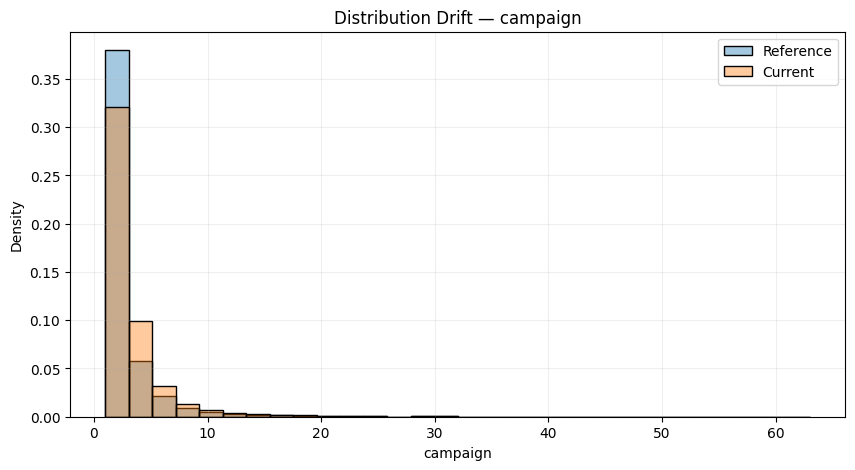

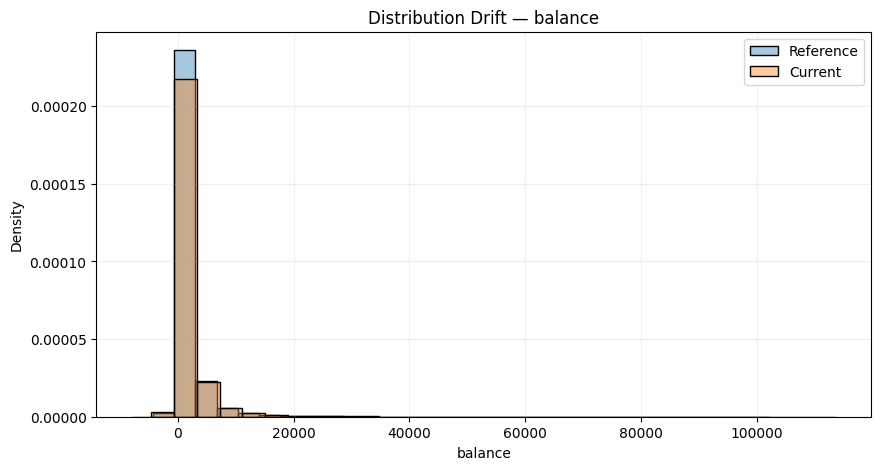

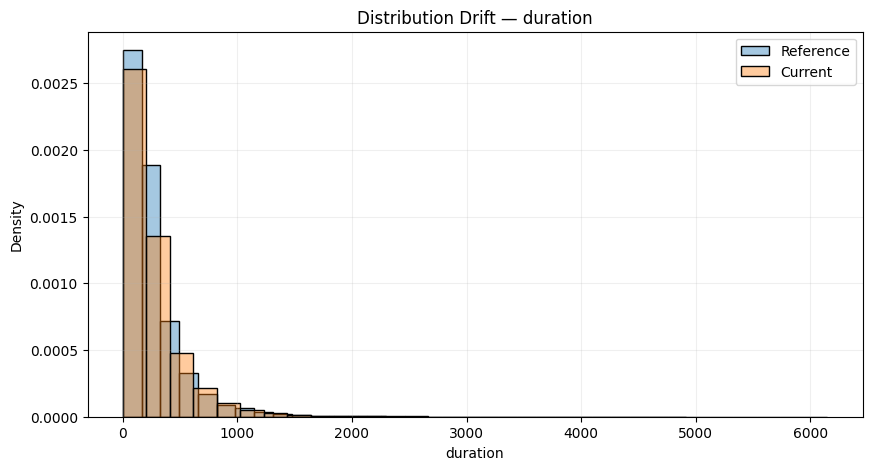

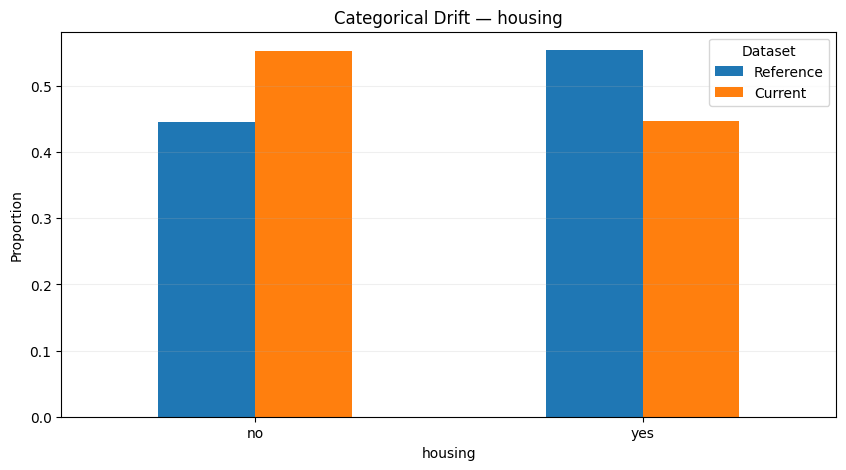

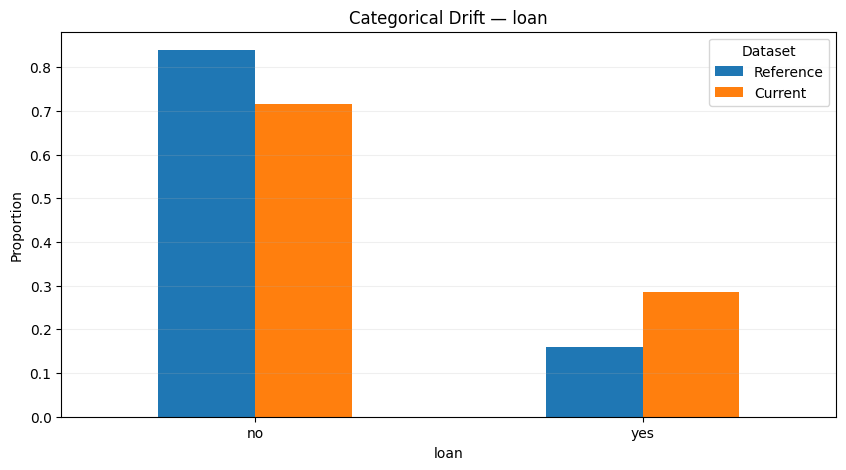

In [11]:
# ============================================================
# PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING
# STEP 8 — DRIFT DISTRIBUTION VISUALIZATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Identify important drift features
# ------------------------------------------------------------

priority_features = (
    alert_report[
        alert_report[
            "Unified_Status"
        ] != "PASS"
    ]
    ["Feature"]
    .tolist()
)

print("=" * 80)
print("DRIFT DISTRIBUTION VISUALIZATION")
print("=" * 80)

print(
    "\nFeatures requiring visualization:"
)

print(
    priority_features
)

# ------------------------------------------------------------
# 2. Numeric features
# ------------------------------------------------------------

numeric_priority = [
    feature
    for feature in priority_features
    if feature in numeric_features
]

for feature in numeric_priority:

    plt.figure(
        figsize=(10, 5)
    )

    sns.histplot(
        reference_df[feature],
        bins=30,
        stat="density",
        alpha=0.4,
        label="Reference"
    )

    sns.histplot(
        current_df[feature],
        bins=30,
        stat="density",
        alpha=0.4,
        label="Current"
    )

    plt.title(
        f"Distribution Drift — {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Density")

    plt.legend()

    plt.grid(
        alpha=0.2
    )

    plt.show()

# ------------------------------------------------------------
# 3. Categorical features
# ------------------------------------------------------------

categorical_priority = [
    feature
    for feature in priority_features
    if feature in categorical_features
]

for feature in categorical_priority:

    reference_dist = (
        reference_df[feature]
        .fillna("__MISSING__")
        .value_counts(
            normalize=True
        )
    )

    current_dist = (
        current_df[feature]
        .fillna("__MISSING__")
        .value_counts(
            normalize=True
        )
    )

    categories = sorted(
        set(reference_dist.index)
        |
        set(current_dist.index)
    )

    comparison = pd.DataFrame({
        "Reference": (
            reference_dist
            .reindex(
                categories,
                fill_value=0
            )
        ),
        "Current": (
            current_dist
            .reindex(
                categories,
                fill_value=0
            )
        )
    })

    plt.figure(
        figsize=(10, 5)
    )

    comparison.plot(
        kind="bar",
        ax=plt.gca()
    )

    plt.title(
        f"Categorical Drift — {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Proportion")

    plt.xticks(
        rotation=0
    )

    plt.legend(
        title="Dataset"
    )

    plt.grid(
        axis="y",
        alpha=0.2
    )

    plt.show()

MULTI-BATCH DRIFT MONITORING


,Batch,Average_Numeric_PSI,Maximum_Numeric_PSI,Average_Categorical_TVD,Maximum_Categorical_TVD,Combined_Drift_Score,Status
0,1,0.000000,0.000000,0.000000,0.0000,0.000000,PASS
1,2,0.001420,0.003013,0.008737,0.0167,0.046527,PASS
2,3,0.001412,0.003580,0.023375,0.0890,0.119699,PASS
3,4,0.013637,0.075296,0.039487,0.1631,0.224711,PASS
4,5,0.031022,0.175185,0.058813,0.2636,0.356106,INVESTIGATE


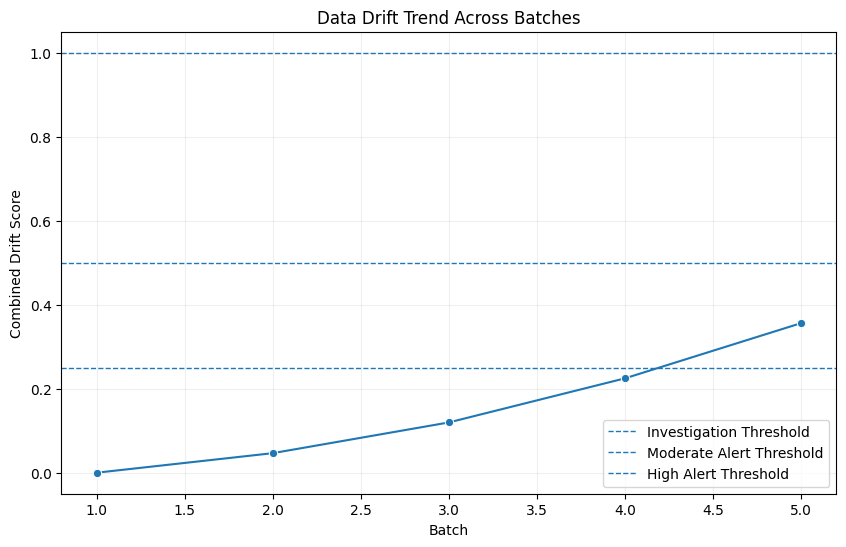

In [12]:
# ============================================================
# PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING
# STEP 9 — MULTI-BATCH DRIFT MONITORING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Create base batches from the original dataset
# ------------------------------------------------------------

if "df" not in globals():
    raise ValueError(
        "Dataset df belum tersedia."
    )

rng = np.random.default_rng(42)

batch_size = min(
    10000,
    len(df)
)

base_features = (
    numeric_features
    +
    categorical_features
    +
    ["y"]
)

# ------------------------------------------------------------
# 2. Create five reference/current-style batches
# ------------------------------------------------------------

batches = {}

for batch_number in range(1, 6):

    batch = (
        df[
            base_features
        ]
        .sample(
            n=batch_size,
            random_state=100 + batch_number
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Batch 1–2: stable
    # Batch 3: early drift
    # Batch 4: stronger drift
    # Batch 5: strongest drift
    # --------------------------------------------------------

    if batch_number >= 3:

        drift_strength = {
            3: 0.10,
            4: 0.20,
            5: 0.30
        }[batch_number]

        # ------------------------------
        # Numeric drift: balance
        # ------------------------------

        mask_balance = (
            rng.random(
                len(batch)
            ) < drift_strength
        )

        batch.loc[
            mask_balance,
            "balance"
        ] = np.round(
            batch.loc[
                mask_balance,
                "balance"
            ]
            * (
                1
                +
                drift_strength
            )
        )

        # ------------------------------
        # Numeric drift: campaign
        # ------------------------------

        mask_campaign = (
            rng.random(
                len(batch)
            ) < drift_strength
        )

        batch.loc[
            mask_campaign,
            "campaign"
        ] = (
            batch.loc[
                mask_campaign,
                "campaign"
            ]
            + (
                2
                *
                batch_number
                / 5
            )
        )

        batch["campaign"] = (
            batch["campaign"]
            .round()
            .astype(
                df["campaign"].dtype
            )
        )

        # ------------------------------
        # Numeric drift: duration
        # ------------------------------

        mask_duration = (
            rng.random(
                len(batch)
            ) < drift_strength
        )

        batch.loc[
            mask_duration,
            "duration"
        ] = np.round(
            batch.loc[
                mask_duration,
                "duration"
            ]
            * (
                1
                +
                drift_strength * 0.8
            )
        )

        batch["duration"] = (
            batch["duration"]
            .round()
            .astype(
                df["duration"].dtype
            )
        )

        # ------------------------------
        # Categorical drift: housing
        # ------------------------------

        mask_housing = (
            rng.random(
                len(batch)
            ) < drift_strength
        )

        batch.loc[
            mask_housing,
            "housing"
        ] = "no"

        # ------------------------------
        # Categorical drift: loan
        # ------------------------------

        mask_loan = (
            rng.random(
                len(batch)
            ) < drift_strength
        )

        batch.loc[
            mask_loan,
            "loan"
        ] = "yes"

    batches[
        batch_number
    ] = batch

# ------------------------------------------------------------
# 3. Compare each batch against reference
# ------------------------------------------------------------

reference_batch = batches[1]

batch_drift_rows = []

for batch_number in range(1, 6):

    current_batch = batches[
        batch_number
    ]

    # --------------------------------------------------------
    # Numeric PSI
    # --------------------------------------------------------

    numeric_psi_values = []

    for feature in numeric_features:

        psi_value = calculate_psi(
            reference_batch[feature],
            current_batch[feature],
            bins=10
        )

        numeric_psi_values.append(
            psi_value
        )

    average_numeric_psi = (
        np.mean(
            numeric_psi_values
        )
    )

    maximum_numeric_psi = (
        np.max(
            numeric_psi_values
        )
    )

    # --------------------------------------------------------
    # Categorical TVD
    # --------------------------------------------------------

    categorical_tvd_values = []

    for feature in categorical_features:

        result = (
            calculate_categorical_drift(
                reference_batch[feature],
                current_batch[feature]
            )
        )

        categorical_tvd_values.append(
            result["TVD"]
        )

    average_categorical_tvd = (
        np.mean(
            categorical_tvd_values
        )
    )

    maximum_categorical_tvd = (
        np.max(
            categorical_tvd_values
        )
    )

    # --------------------------------------------------------
    # Overall drift indicator
    # --------------------------------------------------------

    combined_drift_score = (
        (
            average_numeric_psi
            /
            PSI_HIGH
        )
        +
        (
            average_categorical_tvd
            /
            TVD_MODERATE
        )
    ) / 2

    # --------------------------------------------------------
    # Determine batch status
    # --------------------------------------------------------

    if combined_drift_score >= 1:
        batch_status = "HIGH ALERT"

    elif combined_drift_score >= 0.5:
        batch_status = "MODERATE ALERT"

    elif combined_drift_score >= 0.25:
        batch_status = "INVESTIGATE"

    else:
        batch_status = "PASS"

    batch_drift_rows.append({
        "Batch": batch_number,
        "Average_Numeric_PSI":
            average_numeric_psi,
        "Maximum_Numeric_PSI":
            maximum_numeric_psi,
        "Average_Categorical_TVD":
            average_categorical_tvd,
        "Maximum_Categorical_TVD":
            maximum_categorical_tvd,
        "Combined_Drift_Score":
            combined_drift_score,
        "Status":
            batch_status
    })

batch_drift_report = (
    pd.DataFrame(
        batch_drift_rows
    )
)

# ------------------------------------------------------------
# 4. Display batch monitoring report
# ------------------------------------------------------------

print("=" * 90)
print("MULTI-BATCH DRIFT MONITORING")
print("=" * 90)

display(
    batch_drift_report
)

# ------------------------------------------------------------
# 5. Visualize overall drift trend
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

sns.lineplot(
    data=batch_drift_report,
    x="Batch",
    y="Combined_Drift_Score",
    marker="o"
)

plt.axhline(
    0.25,
    linestyle="--",
    linewidth=1,
    label="Investigation Threshold"
)

plt.axhline(
    0.50,
    linestyle="--",
    linewidth=1,
    label="Moderate Alert Threshold"
)

plt.axhline(
    1.00,
    linestyle="--",
    linewidth=1,
    label="High Alert Threshold"
)

plt.title(
    "Data Drift Trend Across Batches"
)

plt.xlabel(
    "Batch"
)

plt.ylabel(
    "Combined Drift Score"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

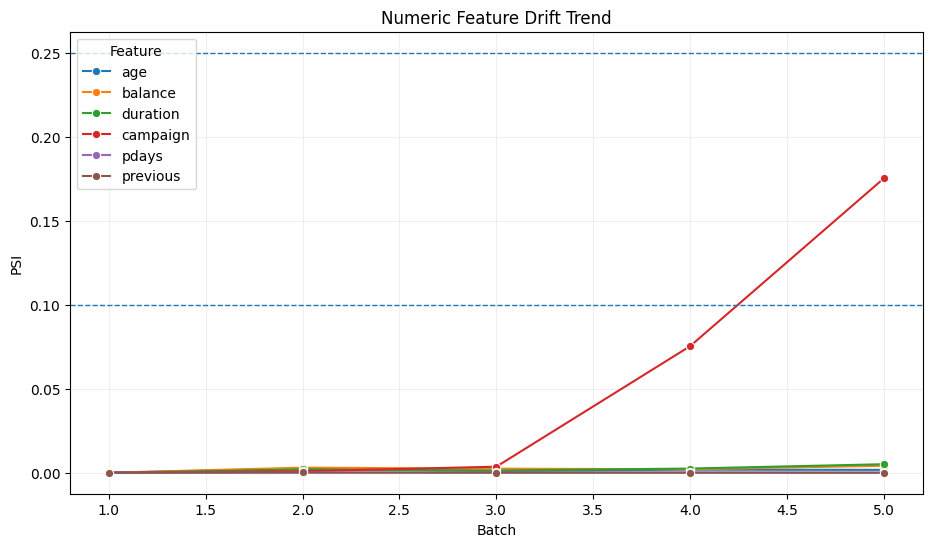

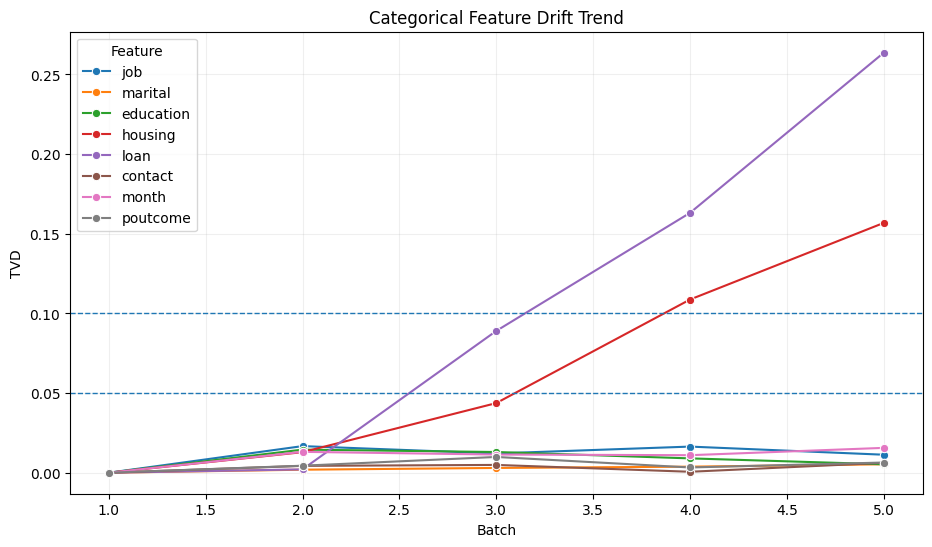

EARLIEST DRIFT DETECTION


,Feature,Metric,First_Drift_Batch
0,age,PSI,NaN
1,balance,PSI,NaN
2,duration,PSI,NaN
3,campaign,PSI,5.0
4,pdays,PSI,NaN
5,previous,PSI,NaN
6,job,TVD,NaN
7,marital,TVD,NaN
8,education,TVD,NaN
9,housing,TVD,4.0


In [13]:
# ============================================================
# PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING
# STEP 10 — FEATURE DRIFT TREND
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Numeric feature PSI across batches
# ------------------------------------------------------------

numeric_trend_rows = []

for batch_number, current_batch in batches.items():

    for feature in numeric_features:

        psi_value = calculate_psi(
            reference_batch[feature],
            current_batch[feature],
            bins=10
        )

        numeric_trend_rows.append({
            "Batch": batch_number,
            "Feature": feature,
            "PSI": psi_value
        })

numeric_trend = pd.DataFrame(
    numeric_trend_rows
)

# ------------------------------------------------------------
# 2. Plot numeric drift trend
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 6)
)

sns.lineplot(
    data=numeric_trend,
    x="Batch",
    y="PSI",
    hue="Feature",
    marker="o"
)

plt.axhline(
    PSI_LOW,
    linestyle="--",
    linewidth=1,
    label="PSI 0.10"
)

plt.axhline(
    PSI_HIGH,
    linestyle="--",
    linewidth=1,
    label="PSI 0.25"
)

plt.title(
    "Numeric Feature Drift Trend"
)

plt.xlabel(
    "Batch"
)

plt.ylabel(
    "PSI"
)

plt.grid(
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 3. Categorical feature TVD across batches
# ------------------------------------------------------------

categorical_trend_rows = []

for batch_number, current_batch in batches.items():

    for feature in categorical_features:

        result = (
            calculate_categorical_drift(
                reference_batch[feature],
                current_batch[feature]
            )
        )

        categorical_trend_rows.append({
            "Batch": batch_number,
            "Feature": feature,
            "TVD": result["TVD"]
        })

categorical_trend = pd.DataFrame(
    categorical_trend_rows
)

# ------------------------------------------------------------
# 4. Plot categorical drift trend
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 6)
)

sns.lineplot(
    data=categorical_trend,
    x="Batch",
    y="TVD",
    hue="Feature",
    marker="o"
)

plt.axhline(
    TVD_LOW,
    linestyle="--",
    linewidth=1,
    label="TVD 0.05"
)

plt.axhline(
    TVD_MODERATE,
    linestyle="--",
    linewidth=1,
    label="TVD 0.10"
)

plt.title(
    "Categorical Feature Drift Trend"
)

plt.xlabel(
    "Batch"
)

plt.ylabel(
    "TVD"
)

plt.grid(
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 5. Identify earliest detected drift per feature
# ------------------------------------------------------------

early_drift = []

for feature in numeric_features:

    feature_data = (
        numeric_trend[
            numeric_trend["Feature"]
            == feature
        ]
    )

    detected = feature_data[
        feature_data["PSI"]
        >= PSI_LOW
    ]

    if len(detected) > 0:

        first_batch = (
            detected
            .sort_values("Batch")
            .iloc[0]["Batch"]
        )

    else:

        first_batch = np.nan

    early_drift.append({
        "Feature": feature,
        "Metric": "PSI",
        "First_Drift_Batch":
            first_batch
    })

for feature in categorical_features:

    feature_data = (
        categorical_trend[
            categorical_trend["Feature"]
            == feature
        ]
    )

    detected = feature_data[
        feature_data["TVD"]
        >= TVD_LOW
    ]

    if len(detected) > 0:

        first_batch = (
            detected
            .sort_values("Batch")
            .iloc[0]["Batch"]
        )

    else:

        first_batch = np.nan

    early_drift.append({
        "Feature": feature,
        "Metric": "TVD",
        "First_Drift_Batch":
            first_batch
    })

early_drift_report = pd.DataFrame(
    early_drift
)

print("=" * 90)
print("EARLIEST DRIFT DETECTION")
print("=" * 90)

display(
    early_drift_report
)

EXECUTIVE DATA DRIFT MONITORING DASHBOARD

Total Monitored Features : 14
Passed Features          : 9
High Alerts              : 2
Moderate Alerts          : 1
Investigations           : 2

Latest Batch             : 5
Latest Drift Score       : 0.356106
Latest Batch Status      : INVESTIGATE

ACTIVE FEATURE ALERTS


,Feature,Data_Type,Drift_Level,Unified_Status,Recommended_Action
0,housing,Categorical,High,HIGH ALERT,Immediate investigation of current data distri...
1,loan,Categorical,High,HIGH ALERT,Immediate investigation of current data distri...
2,campaign,Numeric,Moderate,MODERATE ALERT,Review feature distribution and monitor next d...
3,balance,Numeric,Low,INVESTIGATE,Check statistical significance and business co...
4,duration,Numeric,Low,INVESTIGATE,Check statistical significance and business co...



TOP NUMERIC DRIFT FEATURES


,Feature,PSI,Drift_Level,Metric
0,campaign,0.157422,Moderate,PSI
1,balance,0.005477,Low,PSI
2,duration,0.003723,Low,PSI



TOP CATEGORICAL DRIFT FEATURES


,Feature,TVD,Drift_Level,Metric
0,loan,0.12395,High,TVD
1,housing,0.10705,High,TVD
2,job,0.00775,Low,TVD



LATEST BATCH ANALYSIS


,Batch,Average_Numeric_PSI,Maximum_Numeric_PSI,Average_Categorical_TVD,Maximum_Categorical_TVD,Combined_Drift_Score,Status
4,5,0.031022,0.175185,0.058813,0.2636,0.356106,INVESTIGATE


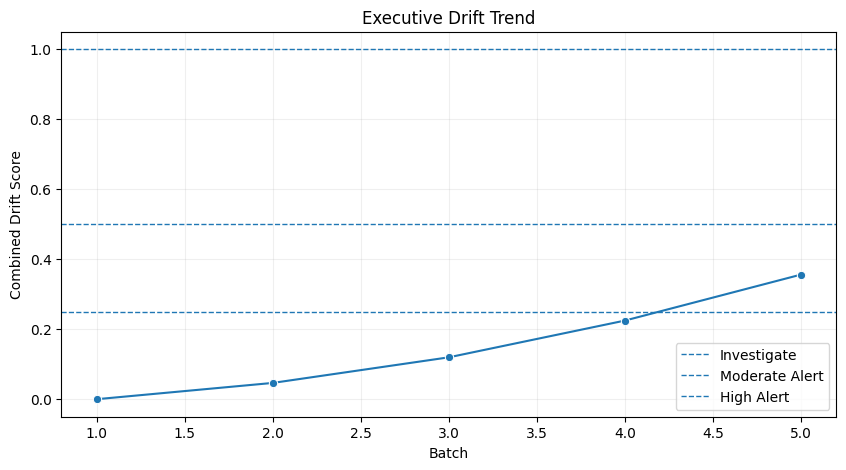

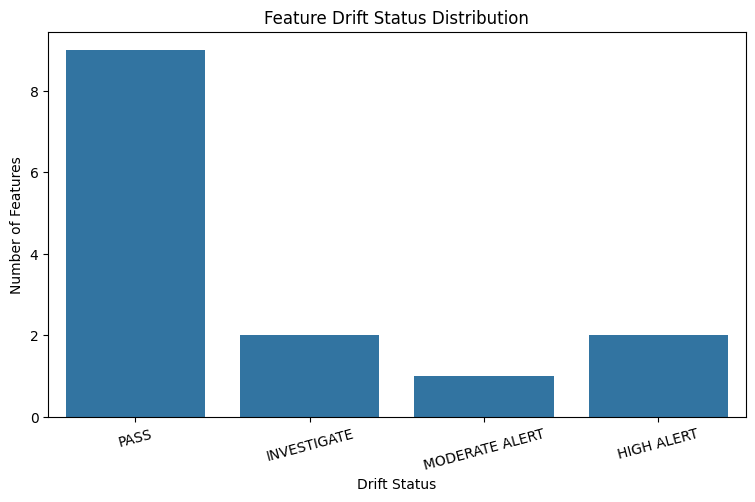


EXECUTIVE INTERPRETATION
The latest data batch shows increasing distributional changes and requires investigation before downstream use.

The monitoring system combines:
PSI + KS Test + TVD + Chi-Square + Multi-Batch Trend Analysis


In [14]:
# ============================================================
# PROJECT 17 — FINANCIAL DATA DRIFT & PIPELINE MONITORING
# STEP 11 — EXECUTIVE DRIFT MONITORING DASHBOARD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Numeric drift summary
# ------------------------------------------------------------

numeric_summary = (
    psi_report[
        [
            "Feature",
            "PSI",
            "Drift_Level"
        ]
    ]
    .copy()
)

numeric_summary["Metric"] = "PSI"

# ------------------------------------------------------------
# 2. Categorical drift summary
# ------------------------------------------------------------

categorical_summary = (
    categorical_drift_report[
        [
            "Feature",
            "TVD",
            "Drift_Level"
        ]
    ]
    .copy()
)

categorical_summary["Metric"] = "TVD"

# ------------------------------------------------------------
# 3. Top drift features
# ------------------------------------------------------------

top_numeric = (
    numeric_summary
    .sort_values(
        "PSI",
        ascending=False
    )
    .head(3)
)

top_categorical = (
    categorical_summary
    .sort_values(
        "TVD",
        ascending=False
    )
    .head(3)
)

# ------------------------------------------------------------
# 4. Current drift status
# ------------------------------------------------------------

active_alerts = (
    alert_report[
        alert_report[
            "Unified_Status"
        ] != "PASS"
    ]
    .copy()
)

# ------------------------------------------------------------
# 5. Overall KPIs
# ------------------------------------------------------------

total_monitored_features = (
    len(unified_drift_report)
)

passed_features = (
    (
        unified_drift_report[
            "Unified_Status"
        ] == "PASS"
    )
    .sum()
)

high_alert_count = (
    (
        unified_drift_report[
            "Unified_Status"
        ] == "HIGH ALERT"
    )
    .sum()
)

moderate_alert_count = (
    (
        unified_drift_report[
            "Unified_Status"
        ] == "MODERATE ALERT"
    )
    .sum()
)

investigate_count = (
    (
        unified_drift_report[
            "Unified_Status"
        ] == "INVESTIGATE"
    )
    .sum()
)

# ------------------------------------------------------------
# 6. Batch trend metrics
# ------------------------------------------------------------

latest_batch = (
    batch_drift_report
    .sort_values("Batch")
    .iloc[-1]
)

latest_batch_number = (
    latest_batch["Batch"]
)

latest_batch_score = (
    latest_batch[
        "Combined_Drift_Score"
    ]
)

latest_batch_status = (
    latest_batch["Status"]
)

# ------------------------------------------------------------
# 7. Print executive summary
# ------------------------------------------------------------

print("=" * 90)
print("EXECUTIVE DATA DRIFT MONITORING DASHBOARD")
print("=" * 90)

print(
    f"\nTotal Monitored Features : "
    f"{total_monitored_features}"
)

print(
    f"Passed Features          : "
    f"{passed_features}"
)

print(
    f"High Alerts              : "
    f"{high_alert_count}"
)

print(
    f"Moderate Alerts          : "
    f"{moderate_alert_count}"
)

print(
    f"Investigations           : "
    f"{investigate_count}"
)

print(
    f"\nLatest Batch             : "
    f"{int(latest_batch_number)}"
)

print(
    f"Latest Drift Score       : "
    f"{latest_batch_score:.6f}"
)

print(
    f"Latest Batch Status      : "
    f"{latest_batch_status}"
)

# ------------------------------------------------------------
# 8. Current active alerts
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "ACTIVE FEATURE ALERTS"
)

print(
    "=" * 90
)

if len(active_alerts) > 0:

    display(
        active_alerts[
            [
                "Feature",
                "Data_Type",
                "Drift_Level",
                "Unified_Status",
                "Recommended_Action"
            ]
        ]
    )

else:

    print(
        "No active feature alerts."
    )

# ------------------------------------------------------------
# 9. Top numeric drift
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "TOP NUMERIC DRIFT FEATURES"
)

print(
    "=" * 90
)

display(
    top_numeric
)

# ------------------------------------------------------------
# 10. Top categorical drift
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "TOP CATEGORICAL DRIFT FEATURES"
)

print(
    "=" * 90
)

display(
    top_categorical
)

# ------------------------------------------------------------
# 11. Latest batch analysis
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "LATEST BATCH ANALYSIS"
)

print(
    "=" * 90
)

display(
    batch_drift_report[
        batch_drift_report[
            "Batch"
        ] == latest_batch_number
    ]
)

# ------------------------------------------------------------
# 12. Plot batch drift trend
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 5)
)

sns.lineplot(
    data=batch_drift_report,
    x="Batch",
    y="Combined_Drift_Score",
    marker="o"
)

plt.axhline(
    0.25,
    linestyle="--",
    linewidth=1,
    label="Investigate"
)

plt.axhline(
    0.50,
    linestyle="--",
    linewidth=1,
    label="Moderate Alert"
)

plt.axhline(
    1.00,
    linestyle="--",
    linewidth=1,
    label="High Alert"
)

plt.title(
    "Executive Drift Trend"
)

plt.xlabel(
    "Batch"
)

plt.ylabel(
    "Combined Drift Score"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 13. Plot feature status distribution
# ------------------------------------------------------------

status_counts = (
    unified_drift_report[
        "Unified_Status"
    ]
    .value_counts()
    .reindex(
        [
            "PASS",
            "INVESTIGATE",
            "MODERATE ALERT",
            "HIGH ALERT"
        ],
        fill_value=0
    )
    .reset_index()
)

status_counts.columns = [
    "Status",
    "Feature_Count"
]

plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=status_counts,
    x="Status",
    y="Feature_Count"
)

plt.title(
    "Feature Drift Status Distribution"
)

plt.xlabel(
    "Drift Status"
)

plt.ylabel(
    "Number of Features"
)

plt.xticks(
    rotation=15
)

plt.show()

# ------------------------------------------------------------
# 14. Executive interpretation
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "EXECUTIVE INTERPRETATION"
)

print(
    "=" * 90
)

if latest_batch_status == "INVESTIGATE":

    print(
        "The latest data batch shows increasing "
        "distributional changes and requires "
        "investigation before downstream use."
    )

elif latest_batch_status == "MODERATE ALERT":

    print(
        "The latest data batch shows moderate "
        "drift and should be reviewed before "
        "being used for critical downstream processes."
    )

elif latest_batch_status == "HIGH ALERT":

    print(
        "The latest data batch shows severe "
        "distributional drift and requires immediate review."
    )

else:

    print(
        "The latest data batch remains within "
        "the configured drift monitoring thresholds."
    )

print(
    "\nThe monitoring system combines:"
)

print(
    "PSI + KS Test + TVD + Chi-Square + "
    "Multi-Batch Trend Analysis"
)

## Key Findings

### 1. Data integrity remained stable

The reference and current datasets maintained the same 15-column schema, matching column order, consistent data types, zero missing values, and zero duplicate records.

This demonstrates that distribution drift can occur even when the structural integrity of a data pipeline remains healthy.

### 2. Numeric drift was concentrated in campaign-related behavior

The Population Stability Index identified `campaign` as the most prominent numeric drift feature with a PSI of approximately 0.1547, categorized as moderate drift under the project's operational thresholds.

The Kolmogorov–Smirnov test also detected statistically significant distribution differences for `campaign`, `balance`, and `duration`.

### 3. Categorical drift was strongest in housing and loan status

The categorical analysis identified `loan` and `housing` as the most significant categorical drift features.

Both features exceeded the high-drift TVD threshold and were statistically significant according to the Chi-Square test.

### 4. Multiple statistical methods provided complementary evidence

The project combined:

- PSI for practical numeric distribution change
- KS Test for statistical numeric distribution difference
- TVD for categorical distribution magnitude
- Chi-Square for categorical statistical significance

Using multiple measures provides a more comprehensive perspective than relying on a single drift metric.

### 5. Drift increased across successive data batches

The multi-batch simulation showed a continuous increase in the combined drift score:

```text
Batch 1 → 0.0000
Batch 2 → 0.0465
Batch 3 → 0.1197
Batch 4 → 0.2247
Batch 5 → 0.3561


### STEP 13 — Business Recommendations

```markdown
## Business Recommendations

### Implement Continuous Data Drift Monitoring

Data batches should be compared against a stable reference dataset on a recurring basis.

Monitoring should include both numerical and categorical features.

### Prioritize High-Impact Drift

The strongest drift indicators in this simulation were:

- `loan`
- `housing`
- `campaign`

These features should be investigated first when similar patterns appear in future data batches.

### Combine Statistical and Practical Thresholds

A small p-value does not necessarily represent a business-critical change.

Drift decisions should combine statistical significance with practical magnitude using measures such as PSI and TVD.

### Establish Automated Alerting

A monitoring pipeline should automatically classify features into:

```text
PASS
INVESTIGATE
MODERATE ALERT
HIGH ALERT


### STEP 14 — Conclusion

```markdown
## Conclusion

This project developed a financial data drift monitoring framework designed to identify changes in data distributions across successive data batches.

The workflow combined schema validation, data integrity checks, Population Stability Index, Kolmogorov–Smirnov testing, Total Variation Distance, Chi-Square testing, automated alerting, and multi-batch drift analysis.

The analysis demonstrated that a dataset can maintain structural integrity while simultaneously experiencing meaningful distributional changes.

In the simulated monitoring environment, `campaign` emerged as the most prominent numeric drift feature, while `loan` and `housing` showed the strongest categorical drift.

The multi-batch simulation further demonstrated that drift can develop gradually over time, with the combined drift score increasing from 0.0000 in Batch 1 to 0.3561 in Batch 5.

This progression highlights the importance of monitoring historical drift trends rather than relying solely on one-time comparisons.

Overall, the project demonstrates an end-to-end Data Observability workflow capable of detecting distribution changes, classifying their severity, generating alerts, and supporting proactive data management decisions.

The framework can serve as a foundation for more advanced enterprise data monitoring systems involving data pipelines, machine learning models, dashboards, and automated alerting.